In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("../data/processed/clean_twitter_training.csv")

df.head()

,tweet_id,entity,sentiment,tweet,clean_tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im get borderland murder
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,come border kill
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im get borderland kill
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im come borderland murder
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im get borderland murder


In [2]:
print(df.shape)

print(df['clean_tweet'].isna().sum())

print(df.columns)

(72975, 5)
686
Index(['tweet_id', 'entity', 'sentiment', 'tweet', 'clean_tweet'], dtype='object')


In [3]:


df = df.dropna(subset=['clean_tweet'])

print(df.shape)
print(df['clean_tweet'].isna().sum())

(72289, 5)
0


In [4]:
X = df['clean_tweet']
y = df['sentiment']

In [5]:
print(df['clean_tweet'].isna().sum())
print(df.shape)

0
(72289, 5)


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
    )
X=tfidf.fit_transform(X)

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
model = LogisticRegression(
    random_state=42,
    max_iter=2000,
    C=2
)

### Model Building

### Train

In [9]:
model.fit(X_train,y_train)

LogisticRegression(C=2, max_iter=2000, random_state=42)

### Test

In [10]:
y_pred=model.predict(X_test)
print(y_pred[:10])

['Irrelevant' 'Positive' 'Negative' 'Neutral' 'Negative' 'Negative'
 'Positive' 'Neutral' 'Negative' 'Negative']


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.81      0.69      0.75      2522
    Negative       0.80      0.87      0.83      4379
     Neutral       0.80      0.75      0.78      3526
    Positive       0.79      0.83      0.81      4031

    accuracy                           0.80     14458
   macro avg       0.80      0.79      0.79     14458
weighted avg       0.80      0.80      0.80     14458



In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.7168349702586804
              precision    recall  f1-score   support

  Irrelevant       0.85      0.46      0.60      2522
    Negative       0.69      0.85      0.76      4379
     Neutral       0.75      0.62      0.68      3526
    Positive       0.69      0.81      0.74      4031

    accuracy                           0.72     14458
   macro avg       0.74      0.69      0.70     14458
weighted avg       0.73      0.72      0.71     14458



In [13]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8306128095172223
              precision    recall  f1-score   support

  Irrelevant       0.83      0.75      0.79      2522
    Negative       0.84      0.88      0.86      4379
     Neutral       0.83      0.79      0.81      3526
    Positive       0.82      0.86      0.84      4031

    accuracy                           0.83     14458
   macro avg       0.83      0.82      0.82     14458
weighted avg       0.83      0.83      0.83     14458



In [14]:
print(X_train.shape)
print(X_test.shape)
print(len(y_train))
print(len(y_test))

(57831, 15000)
(14458, 15000)
57831
14458


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1886  221  170  245]
 [ 105 3865  182  227]
 [ 137  299 2801  289]
 [ 133  219  222 3457]]


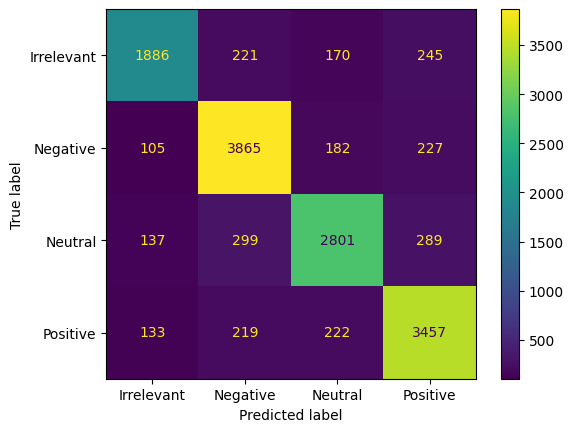

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [17]:
print(tfidf)

TfidfVectorizer(max_df=0.9, max_features=15000, min_df=3, ngram_range=(1, 2),
                sublinear_tf=True)


In [18]:
import joblib

In [19]:
import os

print(os.listdir("../models"))

['sentiment_model.pkl', 'tfidf_vectorizer.pkl']


In [20]:
import joblib

joblib.dump(svm, "../models/sentiment_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [21]:
import os

print(os.listdir("../models"))

['sentiment_model.pkl', 'tfidf_vectorizer.pkl']


In [22]:
import joblib

model = joblib.load("../models/sentiment_model.pkl")
vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

print(type(model))
print(type(vectorizer))

<class 'sklearn.svm._classes.LinearSVC'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [23]:
# Model Training
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9113970016081341
Test Accuracy : 0.8306128095172223
